# HYCOM like vertical coordiantes

This notebook generates versions of a HYCOM like vertical coordinate from `hycom1_75_800m.nc`.
The purpose is to have a HYCOM like vertical coordinate that transitions to isopycnals at shallower depths.
To do this we use the same potential density profile as in `hycom1_75_800m.nc` and change the minimum depth the target potential densities can be found at. 

With a more brute force constant dz in the upper ocean we achieved this but there were two issues:
- the upper ocean had much coarser resolution than the default HYCOM;
- setting constant dz was found by trial and error with no guarantee that it would not error at latter stages.

In [1]:
# Need to be in this directory to use the already configure environment
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir
    cd(tub_output_dir)
end
include(joinpath(tub_output_dir, "plotting.jl"))

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar
│        - hycom
│        - dz3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


In [2]:
# change to this directory
input_dir = "/g/data/e14/jb2381/anu-tub/input/anu-tub"
if pwd() != input_dir
    cd(input_dir)
end
# load the hycom target densities and layer dz
hycom_file = "hycom1_75_800m.nc"
ds = NCDataset(hycom_file)
target_densities = ds["sigma2"][:]
target_dz = ds["dz"][:]
close(ds)

target_z = vcat(0, cumsum(target_dz))
nothing

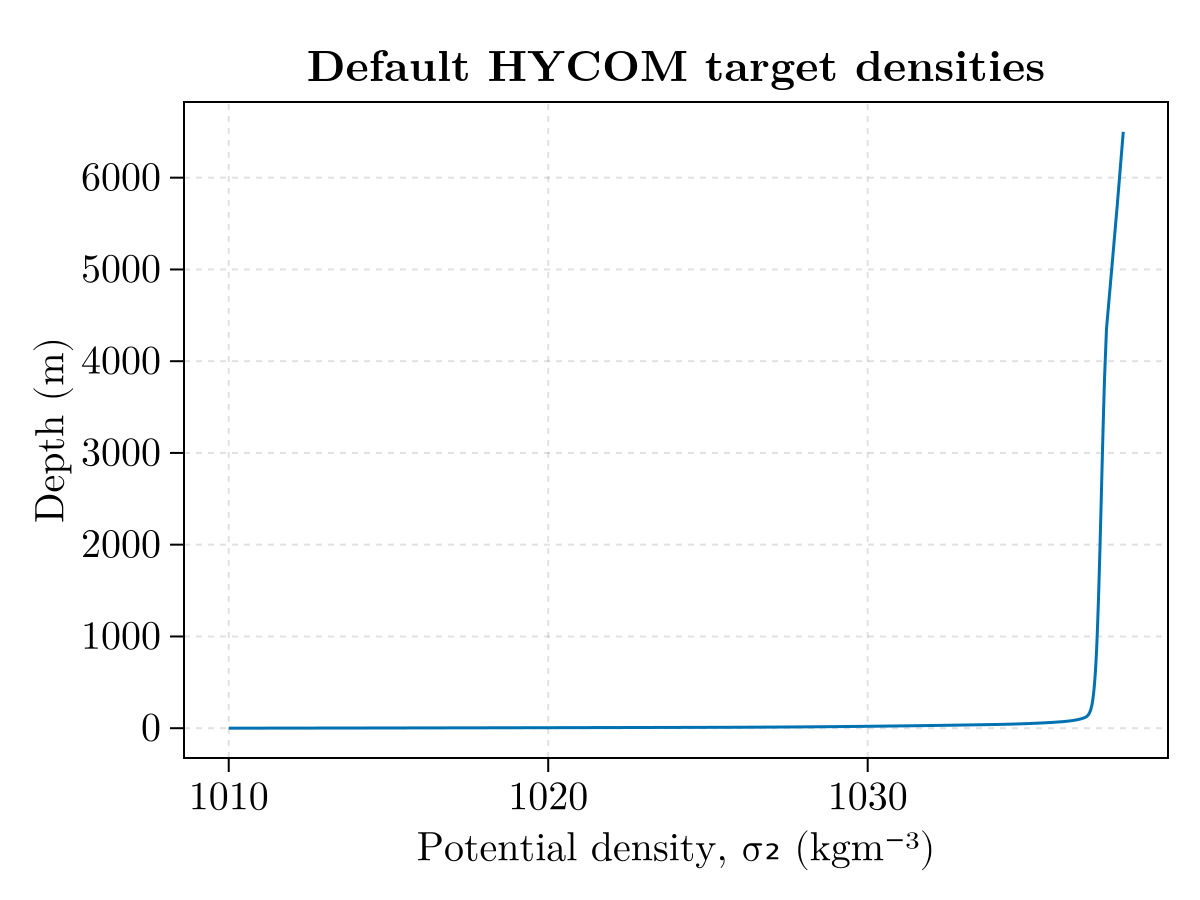

In [9]:
fig, ax = lines(target_densities, target_z)
ax.xlabel = "Potential density, σ₂ (kgm⁻³)"
ax.ylabel = "Depth (m)"
ax.title = "Default HYCOM target densities"
fig

Can see in this target profile that the majority of the depth change occurs at the end of the profile.
Ideally we want to match the surface zstar, but have denser waters found at shallower depths.

With `dz=3` constant, we had a transition to isopycnals around 225m at high latitudes.
As a first step could try something similar to this.
What this means is that the densest water has to be allowed to be found at ~200m.

## Change to constant dz after some chosen depth

I am going to create a few profiles to try.
These will find a depth, then increase with constant dz, from `target_dz`, until the end of the density profile.

In [4]:
target_50 = findfirst(target_z .> 50)
transition_50 = vcat(target_dz[1:target_50], fill(target_dz[target_50], 75 - target_50))
target_100 = findfirst(target_z .> 100)
transition_100 = vcat(target_dz[1:target_100], fill(target_dz[target_100], 75 - target_100))
target_200 = findfirst(target_z .> 200)
transition_200 = vcat(target_dz[1:target_200], fill(target_dz[target_200], 75 - target_200))

z_50 = vcat(0, cumsum(transition_50))
z_100 = vcat(0, cumsum(transition_100))
z_200 = vcat(0, cumsum(transition_200))
nothing

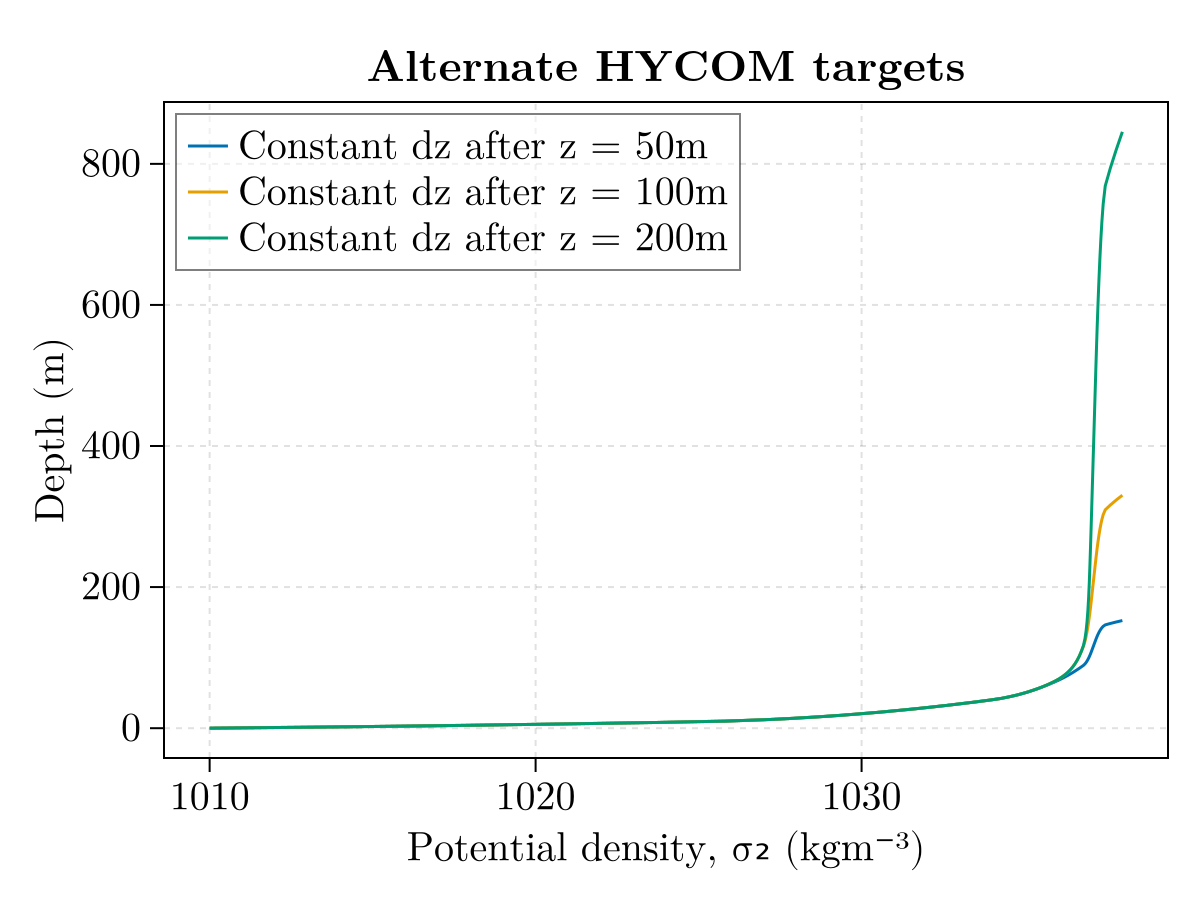

In [6]:
fig, ax = lines(target_densities, z_50, label = "Constant dz after z = 50m")
lines!(ax, target_densities, z_100, label = "Constant dz after z = 100m")
lines!(ax, target_densities, z_200, label = "Constant dz after z = 200m")
# lines!(ax, target_densities, target_z, label = "HYCOM default")
axislegend(ax, position = :lt)
ax.xlabel = "Potential density, σ₂ (kgm⁻³)"
ax.ylabel = "Depth (m)"
ax.title = "Alternate HYCOM targets"
fig

In [10]:
zs2dz_transition = 200

new_dz = zs2dz_transition == 50 ? transition_50 : zs2dz_transition == 100 ? transition_100 : transition_200

ds = NCDataset(hycom_file)
NCDataset(joinpath(pwd(), "hycom1_75_zs2dztransition_$(zs2dz_transition)m.nc"), "c") do new_ds
    defDim(new_ds, "layers", ds.dim["layers"])
    defDim(new_ds, "interfaces", ds.dim["interfaces"])
    defVar(new_ds, ds["sigma2"])
    defVar(new_ds, "dz", new_dz, ("layers",), attrib = ds["dz"].attrib)
    new_ds.attrib["File info"] = "This file uses the target densities from hycom1_75_800.nc and uses the same zstar profile until a depth of $(zs2dz_transition)m. After this point constant dz =  is set."
    new_ds.attrib["Quasi author"] = "Josef I. Bisits"
end
close(ds)

closed Dataset

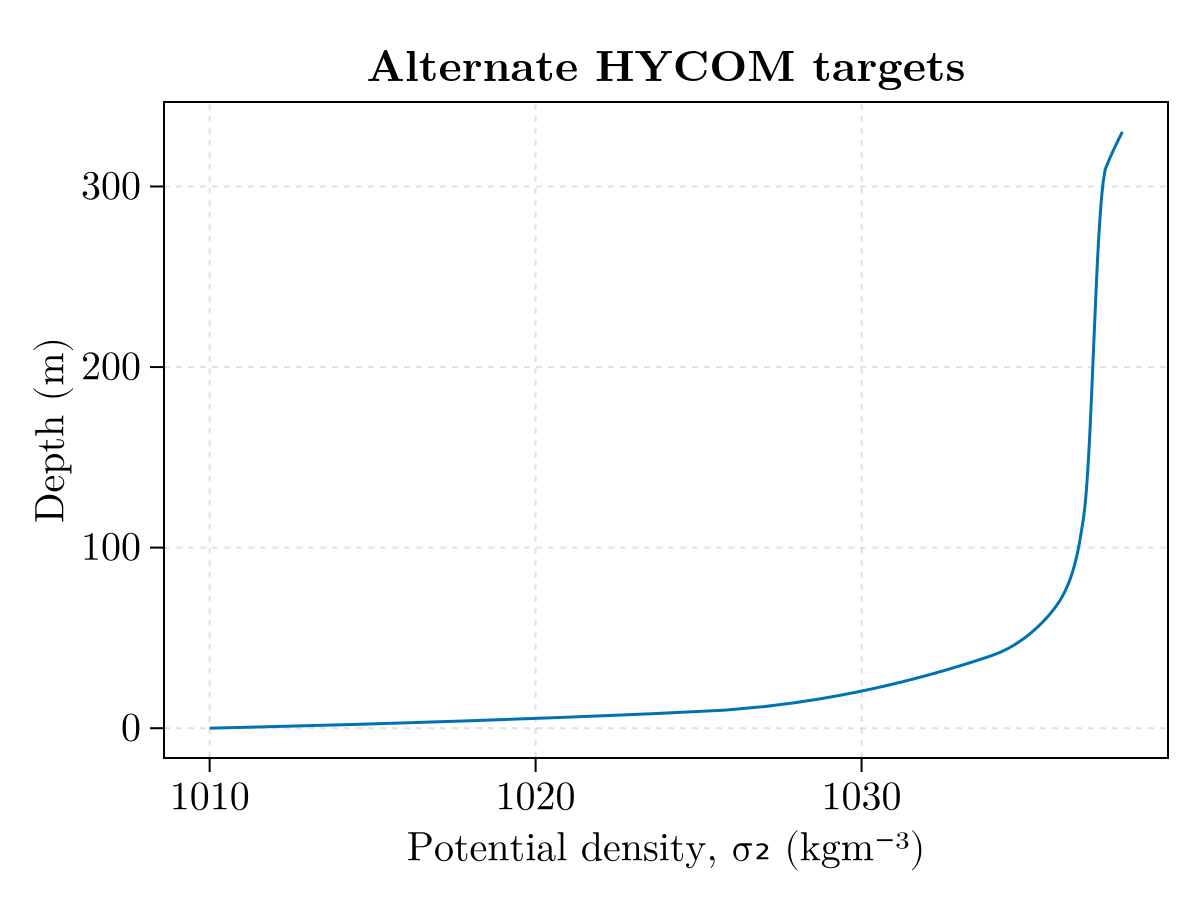

In [12]:
ds = NCDataset("hycom1_75_zs2dztransition_100m.nc")
fig, ax = lines(ds["sigma2"][:], vcat(0, cumsum(ds["dz"][:])), label = "Constant dz after z = 50m")
ax.xlabel = "Potential density, σ₂ (kgm⁻³)"
ax.ylabel = "Depth (m)"
ax.title = "Alternate HYCOM targets"
close(ds)
fig